## 강원도 신재생에너지 개발 현황 데이터 분석
이 프로젝트는 강원도 내 신재생에너지 발전 설비 현황, 발전 성과,
정책 지원, 기상 요인을 종합하여 지역별 개발 특성과
향후 개발 가능성을 분석하는 것을 목표로 한다.

### 분석 흐름
1. 발전 설비 현황 수집
2. 발전량 데이터 결합
3. 정책·지원 사업 반영
4. 기상 요인 영향 분석

In [19]:
print(energy.columns)
print(energy.head())

Index(['연도', '광역지자체', '기초지자체', '신재생에너지 합계', '재생에너지 합계', '신에너지 합계',
       '신재생에너지공급비중', '태양광', '풍력', '수력', '해양', '바이오', '재생폐기물', '연료전지', 'IGCC'],
      dtype='object')
     연도 광역지자체 기초지자체  신재생에너지 합계   재생에너지 합계  신에너지 합계  신재생에너지공급비중      태양광  \
0  2021    강원   강릉시  2,088,289  2,088,224       65       35.46  131,258   
1  2021    강원   고성군    142,575    142,575        -        2.42  141,704   
2  2021    강원    기타      4,429      4,403       26        0.08    2,769   
3  2021    강원   동해시    405,359    273,611  131,748        6.88   26,993   
4  2021    강원   삼척시    280,341    280,337        3        4.76  110,382   

       풍력      수력 해양        바이오 재생폐기물     연료전지 IGCC  
0  81,395   3,230  -  1,872,341     -       65    -  
1       -     871  -          -     -        -    -  
2   1,634       -  -          -     -       26    -  
3       -  30,284  -    216,335     -  131,748    -  
4  33,271  13,449  -    123,235     -        3    -  


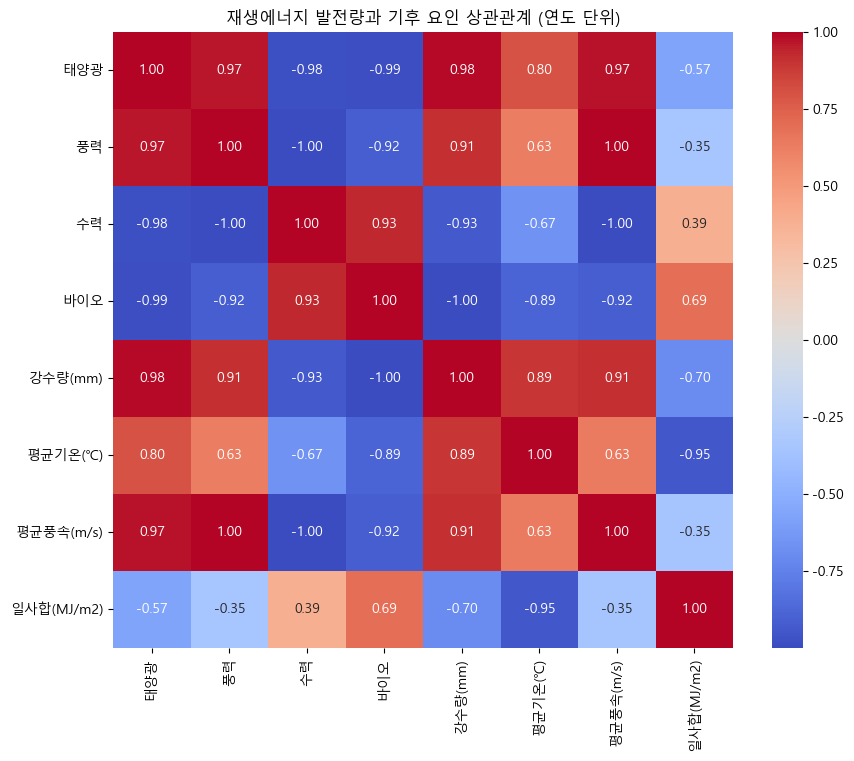

📊 상관관계 테이블:
                 태양광        풍력        수력       바이오   강수량(mm)   평균기온(℃)  \
태양광         1.000000  0.968719 -0.979398 -0.987317  0.984944  0.802585   
풍력          0.968719  1.000000 -0.998875 -0.917035  0.911233  0.629442   
수력         -0.979398 -0.998875  1.000000  0.934917 -0.929742 -0.665586   
바이오        -0.987317 -0.917035  0.934917  1.000000 -0.999898 -0.887112   
강수량(mm)     0.984944  0.911233 -0.929742 -0.999898  1.000000  0.893627   
평균기온(℃)     0.802585  0.629442 -0.665586 -0.887112  0.893627  1.000000   
평균풍속(m/s)   0.970348  0.999978 -0.999168 -0.919668  0.913953  0.634597   
일사합(MJ/m2) -0.567838 -0.345804  0.389915  0.691318 -0.701588 -0.946773   

            평균풍속(m/s)  일사합(MJ/m2)  
태양광          0.970348   -0.567838  
풍력           0.999978   -0.345804  
수력          -0.999168    0.389915  
바이오         -0.919668    0.691318  
강수량(mm)      0.913953   -0.701588  
평균기온(℃)      0.634597   -0.946773  
평균풍속(m/s)    1.000000   -0.352039  
일사합(MJ/m2)  -0.352039    1.000000

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

energy = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx", sheet_name="Sheet1")
rain = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별강수량_통합.xlsx")
temp = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별기온_통합.xlsx")
wind = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별풍속_통합.xlsx")
solar = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월일조일사_통합.xlsx")

for df in [rain, temp, wind, solar]:
    df["연도"] = pd.to_datetime(df["일시"]).dt.year
    df["월"] = pd.to_datetime(df["일시"]).dt.month

rain = rain[["지점명","연도","월","강수량(mm)"]]
temp = temp[["지점명","연도","월","평균기온(℃)"]]
wind = wind[["지점명","연도","월","평균풍속(m/s)"]]
solar = solar[["지점명","연도","월","일사합(MJ/m2)"]]

climate = rain.merge(temp, on=["지점명","연도","월"], how="inner") \
              .merge(wind, on=["지점명","연도","월"], how="inner") \
              .merge(solar, on=["지점명","연도","월"], how="inner")

climate_yearly = climate.groupby(["지점명","연도"]).agg({
    "강수량(mm)":"sum",        
    "일사합(MJ/m2)":"sum",     
    "평균기온(℃)":"mean",      
    "평균풍속(m/s)":"mean"     
}).reset_index()

region_map = {
    "강릉": "강릉시", "북강릉": "강릉시",
    "속초": "속초시", "원주": "원주시",
    "영월": "영월군", "인제": "인제군",
    "동해": "동해시", "대관령": "평창군",
    "북춘천": "춘천시"
}
climate_yearly["기초지자체"] = climate_yearly["지점명"].map(region_map)

for col in ["태양광","풍력","수력","바이오"]:
    energy[col] = energy[col].replace("-", None)
    energy[col] = energy[col].astype(str).str.replace(",", "")
    energy[col] = pd.to_numeric(energy[col], errors="coerce")

merged = pd.merge(energy, climate_yearly, on=["기초지자체","연도"], how="inner")

corr = merged[["태양광","풍력","수력","바이오",
               "강수량(mm)","평균기온(℃)","평균풍속(m/s)","일사합(MJ/m2)"]].corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("재생에너지 발전량과 기후 요인 상관관계 (연도 단위)")
plt.show()

print("📊 상관관계 테이블:")
print(corr)


# climate_yearly.to_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/climate_yearly.xlsx", index=False)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')   # 윈도우: 맑은 고딕
# plt.rc('font', family='NanumGothic')   # 리눅스/맥: 나눔고딕 설치 시 사용
plt.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지

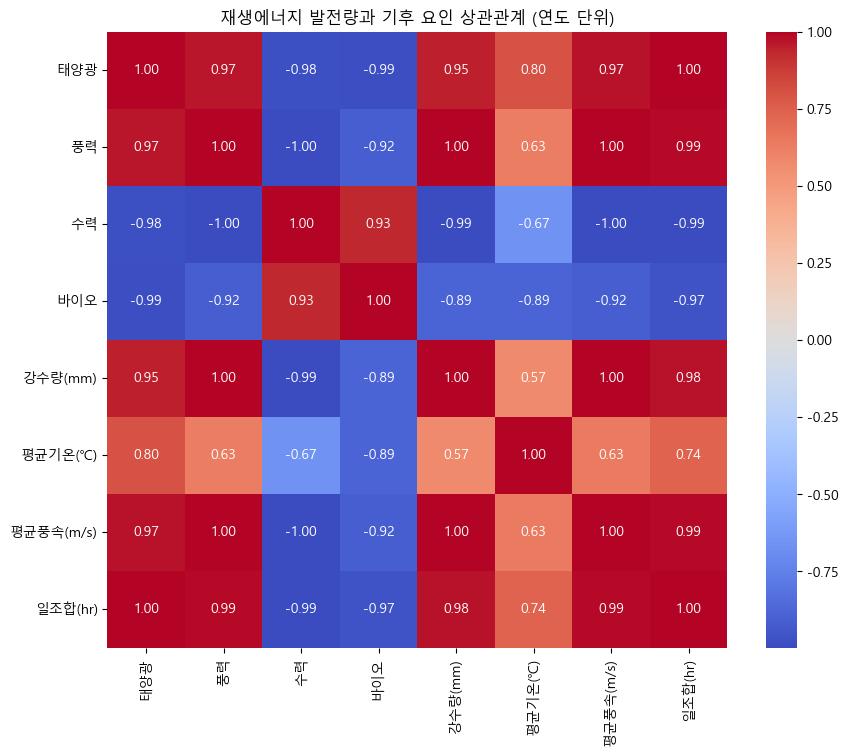

📊 상관관계 테이블:
                태양광        풍력        수력       바이오   강수량(mm)   평균기온(℃)  \
태양광        1.000000  0.968719 -0.979398 -0.987317  0.949163  0.802585   
풍력         0.968719  1.000000 -0.998875 -0.917035  0.997589  0.629442   
수력        -0.979398 -0.998875  1.000000  0.934917 -0.993176 -0.665586   
바이오       -0.987317 -0.917035  0.934917  1.000000 -0.887149 -0.887112   
강수량(mm)    0.949163  0.997589 -0.993176 -0.887149  1.000000  0.574002   
평균기온(℃)    0.802585  0.629442 -0.665586 -0.887112  0.574002  1.000000   
평균풍속(m/s)  0.970348  0.999978 -0.999168 -0.919668  0.997106  0.634597   
일조합(hr)    0.995035  0.988608 -0.994634 -0.966614  0.975780  0.739227   

           평균풍속(m/s)   일조합(hr)  
태양광         0.970348  0.995035  
풍력          0.999978  0.988608  
수력         -0.999168 -0.994634  
바이오        -0.919668 -0.966614  
강수량(mm)     0.997106  0.975780  
평균기온(℃)     0.634597  0.739227  
평균풍속(m/s)   1.000000  0.989587  
일조합(hr)     0.989587  1.000000  


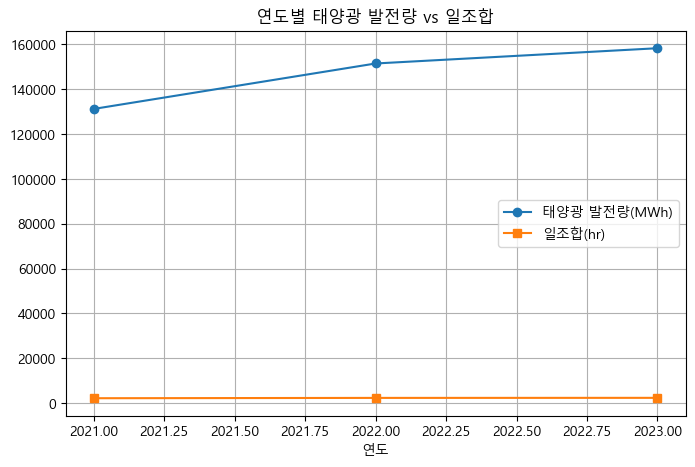

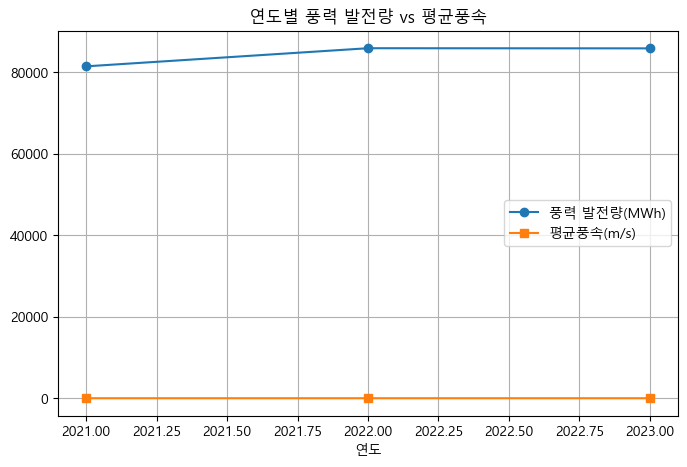

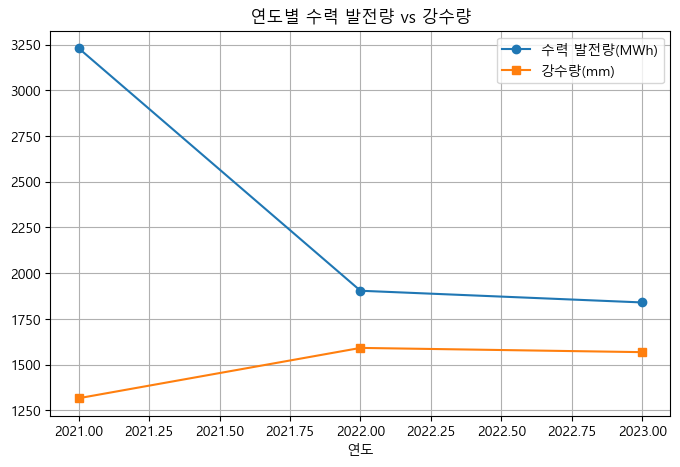

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 최신 기후 데이터 불러오기
rain = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별강수량.xlsx")
temp = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별기온.xlsx")
wind = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별풍속.xlsx")
solar = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별일조일사.xlsx")

# 2. 연도 추출
for df in [rain, temp, wind, solar]:
    df["연도"] = pd.to_datetime(df["일시"]).dt.year

# 3. 필요한 컬럼만 선택
rain = rain[["지점명","연도","강수량(mm)"]]
temp = temp[["지점명","연도","평균기온(℃)"]]
wind = wind[["지점명","연도","평균풍속(m/s)"]]
solar = solar[["지점명","연도","일조합(hr)"]]

# 4. 연도 단위 집계
rain_yearly = rain.groupby(["지점명","연도"]).sum().reset_index()
temp_yearly = temp.groupby(["지점명","연도"]).mean().reset_index()
wind_yearly = wind.groupby(["지점명","연도"]).mean().reset_index()
solar_yearly = solar.groupby(["지점명","연도"]).sum().reset_index()

# 5. 병합
climate_yearly = rain_yearly.merge(temp_yearly, on=["지점명","연도"]) \
                            .merge(wind_yearly, on=["지점명","연도"]) \
                            .merge(solar_yearly, on=["지점명","연도"])

# 6. 지역 매핑
region_map = {
    "강릉": "강릉시", "북강릉": "강릉시",
    "속초": "속초시", "원주": "원주시",
    "영월": "영월군", "인제": "인제군",
    "동해": "동해시", "대관령": "평창군",
    "북춘천": "춘천시"
}
climate_yearly["기초지자체"] = climate_yearly["지점명"].map(region_map)

# 7. 발전량 데이터 불러오기 및 숫자 변환
energy = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx", sheet_name="Sheet1")
for col in ["태양광","풍력","수력","바이오"]:
    energy[col] = energy[col].replace("-", None)
    energy[col] = energy[col].astype(str).str.replace(",", "")
    energy[col] = pd.to_numeric(energy[col], errors="coerce")

# 8. 병합
merged = pd.merge(energy, climate_yearly, on=["기초지자체","연도"], how="inner")

# 9. 상관관계 분석
corr = merged[["태양광","풍력","수력","바이오",
               "강수량(mm)","평균기온(℃)","평균풍속(m/s)","일조합(hr)"]].corr()

# 10. Heatmap 출력
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("재생에너지 발전량과 기후 요인 상관관계 (연도 단위)")
plt.show()

print("📊 상관관계 테이블:")
print(corr)

# 11. 추세 그래프 예시
plt.figure(figsize=(8,5))
plt.plot(merged["연도"], merged["태양광"], marker="o", label="태양광 발전량(MWh)")
plt.plot(merged["연도"], merged["일조합(hr)"], marker="s", label="일조합(hr)")
plt.title("연도별 태양광 발전량 vs 일조합")
plt.xlabel("연도")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(merged["연도"], merged["풍력"], marker="o", label="풍력 발전량(MWh)")
plt.plot(merged["연도"], merged["평균풍속(m/s)"], marker="s", label="평균풍속(m/s)")
plt.title("연도별 풍력 발전량 vs 평균풍속")
plt.xlabel("연도")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(merged["연도"], merged["수력"], marker="o", label="수력 발전량(MWh)")
plt.plot(merged["연도"], merged["강수량(mm)"], marker="s", label="강수량(mm)")
plt.title("연도별 수력 발전량 vs 강수량")
plt.xlabel("연도")
plt.legend()
plt.grid(True)
plt.show()

데이터 타입 확인:
연도              int64
광역지자체          object
기초지자체          object
신재생에너지 합계      object
재생에너지 합계       object
신에너지 합계        object
신재생에너지공급비중    float64
태양광             int64
풍력            float64
수력            float64
해양             object
바이오           float64
재생폐기물          object
연료전지           object
IGCC           object
지점명            object
강수량(mm)       float64
평균기온(℃)       float64
일조합(hr)       float64
평균풍속(m/s)     float64
dtype: object


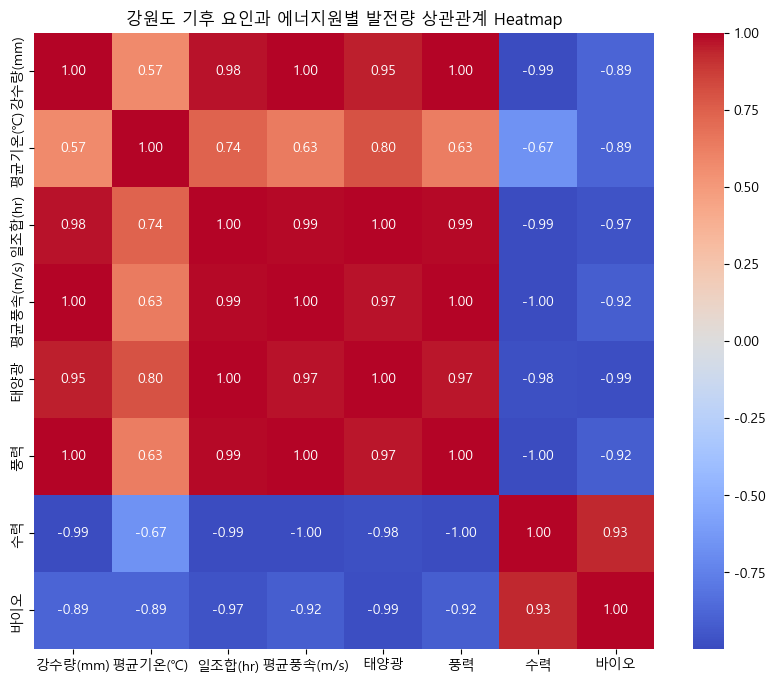

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 발전량 데이터
energy = pd.read_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx",
    sheet_name="Sheet1"
)

# 2. 강수량 데이터
rain = pd.read_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별강수량.xlsx"
)
rain['연도'] = pd.to_datetime(rain['일시']).dt.year
rain_group = rain.groupby(['지점명','연도'])['강수량(mm)'].sum().reset_index()

# 3. 기온 데이터
temp = pd.read_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별기온.xlsx"
)
temp['연도'] = pd.to_datetime(temp['일시']).dt.year
temp_group = temp.groupby(['지점명','연도'])['평균기온(℃)'].mean().reset_index()

# 4. 일조 데이터
sun = pd.read_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별일조일사.xlsx"
)
sun['연도'] = pd.to_datetime(sun['일시']).dt.year
sun_group = sun.groupby(['지점명','연도'])['일조합(hr)'].sum().reset_index()

# 5. 풍속 데이터
wind = pd.read_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별풍속.xlsx"
)
wind['연도'] = pd.to_datetime(wind['일시']).dt.year
wind_group = wind.groupby(['지점명','연도'])['평균풍속(m/s)'].mean().reset_index()

# 6. 기후 데이터 통합
climate = rain_group.merge(temp_group, on=['지점명','연도']) \
                    .merge(sun_group, on=['지점명','연도']) \
                    .merge(wind_group, on=['지점명','연도'])

# 7. 지점명 ↔ 기초지자체 매핑
mapping = {
    "강릉": "강릉시",
    "북강릉": "강릉시",
    "속초": "속초시",
    "동해": "동해시",
    "원주": "원주시",
    "영월": "영월군",
    "인제": "인제군",
    "정선군": "정선군",
    "철원": "철원군",
    "북춘천": "춘천시",
    "대관령": "평창군"
}
climate['기초지자체'] = climate['지점명'].map(mapping)

# 8. 발전량 데이터 숫자형 변환
for col in ["태양광","풍력","수력","바이오"]:
    energy[col] = pd.to_numeric(energy[col].astype(str).str.replace(",",""), errors="coerce")

# 9. 기후 데이터 숫자형 변환
for col in ["강수량(mm)","평균기온(℃)","일조합(hr)","평균풍속(m/s)"]:
    climate[col] = pd.to_numeric(climate[col].astype(str).str.replace(",",""), errors="coerce")

# 10. 병합
merged = energy.merge(climate, on=['기초지자체','연도'])

# 11. 데이터 타입 확인
print("데이터 타입 확인:")
print(merged.dtypes)

# 12. 상관계수 Heatmap
cols = ["강수량(mm)","평균기온(℃)","일조합(hr)","평균풍속(m/s)","태양광","풍력","수력","바이오"]
corr = merged[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("강원도 기후 요인과 에너지원별 발전량 상관관계 Heatmap")
plt.show()

In [22]:
! pip install geopandas

  Using cached geopandas-1.1.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached pyogrio-0.12.1-cp314-cp314-win_amd64.whl.metadata (6.0 kB)
  Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl.metadata (7.1 kB)
Using cached geopandas-1.1.2-py3-none-any.whl (341 kB)
Using cached pyogrio-0.12.1-cp314-cp314-win_amd64.whl (23.6 MB)
Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl (6.4 MB)
Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl (1.8 MB)

   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------- ----------------------------- 1/4 [pyproj]
   ---------- ----------------------------- 1/4 [pyproj]
   -------------------- ------------------- 2/4 [pyogrio]
   -------------------- ------------------- 2/4 [pyogrio]
   -------------------- ------------------- 2/4 [pyogrio]
   --------

In [35]:
print(climate["지점명"].unique())

['강릉시']


In [36]:
print(rain["지점명"].unique())
print(temp["지점명"].unique())
print(sun["지점명"].unique())
print(wind["지점명"].unique())

['강릉']
['강릉']
['강릉']
['강릉']


In [39]:
print("에너지 데이터 지역명:", energy["지점명"].unique())
print("기후 데이터 지역명:", climate["지점명"].unique())
print("마커 지역명:", list(locations.keys()))

에너지 데이터 지역명: ['Sheet1']
기후 데이터 지역명: ['강원도(강릉)' '강원도(대관령)' '강원도(동해)' '강원도(북강릉)' '강원도(북춘천)' '강원도(속초)' '강원도(영월)'
 '강원도(원주)' '강원도(인제)' '강원도(정선군)' '강원도(철원)' '강원도(춘천)' '강원도(태백)' '강원도(홍천)']
마커 지역명: ['강릉시', '속초시', '동해시', '원주시', '춘천시', '영월군', '인제군', '정선군', '평창군', '태백시', '철원군']


In [ ]:
import folium
import pandas as pd
import matplotlib.pyplot as plt
import base64
from io import BytesIO

# -------------------------------
# 1. 에너지 데이터 불러오기
# -------------------------------
energy = pd.read_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx",
    sheet_name="Sheet1"
)
energy.rename(columns={"기초지자체":"지점명"}, inplace=True)
for col in ["태양광","풍력","수력","바이오"]:
    energy[col] = pd.to_numeric(energy[col].astype(str).str.replace(",",""), errors="coerce")

# -------------------------------
# 2. 기후 데이터 불러오기  예리님이 주신 파일 시트별로 정리되어 있어서 하나로 합친 함수입니다.
# -------------------------------
def load_multi_sheet_excel(path):
    xls = pd.ExcelFile(path)
    dfs = []
    for sheet in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet)
        df["지점명"] = sheet
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

rain = load_multi_sheet_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별강수량.xlsx"
)
rain['연도'] = pd.to_datetime(rain['일시']).dt.year
rain_group = rain.groupby(['지점명','연도'])['강수량(mm)'].sum().reset_index()

temp = load_multi_sheet_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별기온.xlsx"
)
temp['연도'] = pd.to_datetime(temp['일시']).dt.year
temp_group = temp.groupby(['지점명','연도'])['평균기온(℃)'].mean().reset_index()

sun = load_multi_sheet_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별일조일사.xlsx"
)
sun['연도'] = pd.to_datetime(sun['일시']).dt.year
sun_group = sun.groupby(['지점명','연도'])['일조합(hr)'].sum().reset_index()

wind = load_multi_sheet_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별풍속.xlsx"
)
wind['연도'] = pd.to_datetime(wind['일시']).dt.year
wind_group = wind.groupby(['지점명','연도'])['평균풍속(m/s)'].mean().reset_index()

climate = rain_group.merge(temp_group, on=['지점명','연도']) \
                    .merge(sun_group, on=['지점명','연도']) \
                    .merge(wind_group, on=['지점명','연도'])

# -------------------------------
# 3. 기후 데이터 지역명 정리 
# -------------------------------
climate["지점명"] = climate["지점명"].str.extract(r"\((.*?)\)")
name_map = {
    "강릉":"강릉시","속초":"속초시","동해":"동해시","원주":"원주시","춘천":"춘천시",
    "영월":"영월군","인제":"인제군","정선군":"정선군","평창":"평창군",
    "태백":"태백시","철원":"철원군","홍천":"홍천군"
}
climate["지점명"] = climate["지점명"].replace(name_map)

# -------------------------------
# 4. 좌표 매핑
# -------------------------------
locations = {
    "강릉시": [37.75,128.90],
    "속초시": [38.20,128.59],
    "동해시": [37.52,129.12],
    "원주시": [37.34,127.92],
    "춘천시": [37.88,127.73],
    "영월군": [37.18,128.46],
    "인제군": [38.06,128.17],
    "정선군": [37.38,128.66],
    "평창군": [37.37,128.39],
    "태백시": [37.16,128.99],
    "철원군": [38.20,127.31],
    "홍천군": [37.69,127.88]
}
marker_cities = list(locations.keys())

# -------------------------------
# 5. 지도 생성
# -------------------------------
m = folium.Map(location=[37.7, 128.3], zoom_start=8)

geojson_url = "https://raw.githubusercontent.com/raqoon886/Local_HangJeongDong/master/hangjeongdong_%EA%B0%95%EC%9B%90%EB%8F%84.geojson"        # 깃허브에서 가져온 지도입니다.
folium.GeoJson(
    geojson_url,
    name="강원도 시군구 경계",
    style_function=lambda feature: {
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.4,
        "fillColor": "lightgreen" if feature["properties"]["adm_nm"] in marker_cities else "lightgray"
    },
    highlight_function=lambda feature: {
        "fillColor": "yellow",
        "color": "red",
        "weight": 3,
        "fillOpacity": 0.7
    },
    tooltip=folium.GeoJsonTooltip(fields=["adm_nm"], aliases=["행정구역"])
).add_to(m)

def fmt(val, unit=""):
    return f"{val:,.1f} {unit}" if val is not None else "데이터 없음"

for city, coord in locations.items():
    row = energy.loc[energy["지점명"]==city].iloc[0] if city in energy["지점명"].values else None

    rain_val = climate.loc[climate["지점명"]==city, "강수량(mm)"].mean() if city in climate["지점명"].values else None
    sun_val  = climate.loc[climate["지점명"]==city, "일조합(hr)"].mean() if city in climate["지점명"].values else None
    wind_val = climate.loc[climate["지점명"]==city, "평균풍속(m/s)"].mean() if city in climate["지점명"].values else None

    if row is not None:
        fig, ax = plt.subplots(figsize=(4,3))
        sources = ["태양광","풍력","수력","바이오"]
        values = [row["태양광"], row["풍력"], row["수력"], row["바이오"]]
        colors = ["#FDB813","#00BFFF","#228B22","#8B4513"]
        ax.bar(sources, values, color=colors)
        ax.set_title(f"{city} 재생에너지 발전량", fontsize=12)
        ax.set_ylabel("MWh")
        plt.tight_layout()
        buf = BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        energy_img = base64.b64encode(buf.read()).decode("utf-8")
        plt.close(fig)
    else:
        energy_img = None

    climate_img = None
    if city in climate["지점명"].values:
        city_climate = climate[climate["지점명"]==city]
        fig, ax = plt.subplots(figsize=(5,3))
        ax.plot(city_climate["연도"], city_climate["강수량(mm)"], label="강수량(mm)", color="blue")
        ax.plot(city_climate["연도"], city_climate["일조합(hr)"], label="일조합(hr)", color="orange")
        ax.plot(city_climate["연도"], city_climate["평균풍속(m/s)"], label="풍속(m/s)", color="green")
        ax.set_title(f"{city} 연도별 기후 추세", fontsize=12)
        ax.set_xlabel("연도")
        ax.legend()
        plt.tight_layout()
        buf = BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        climate_img = base64.b64encode(buf.read()).decode("utf-8")
        plt.close(fig)

    # 팝업 HTML
    popup_html = f"""
    <div style="font-family:Arial; font-size:14px; line-height:1.6; color:#333;">
        <h4 style="margin:0; color:#2a7ae2;">📍 {city}</h4>
        <p style="margin:5px 0; color:#555;">재생에너지 발전량</p>
        <ul style="padding-left:15px; margin:5px 0;">
            <li>🌞 <b>태양광</b>: {fmt(row['태양광'] if row is not None else None,"MWh")}</li>
            <li>💨 <b>풍력</b>: {fmt(row['풍력'] if row is not None else None,"MWh")}</li>
            <li>💧 <b>수력</b>: {fmt(row['수력'] if row is not None else None,"MWh")}</li>
            <li>🌱 <b>바이오</b>: {fmt(row['바이오'] if row is not None else None,"MWh")}</li>
        </ul>
        <p style="margin:5px 0; color:#555;">기후 요인</p>
        <ul style="padding-left:15px; margin:5px 0;">
            <li>☔ <b>강수량</b>: {fmt(rain_val,"mm")}</li>
            <li>🌞 <b>일조합</b>: {fmt(sun_val,"hr")}</li>
            <li>🍃 <b>평균풍속</b>: {fmt(wind_val,"m/s")}</li>
        </ul>
        {f'<img src="data:image/png;base64,{energy_img}" width="300"><br>' if energy_img else ''}
        {f'<img src="data:image/png;base64,{climate_img}" width="400">' if climate_img else ''}
    </div>
    """

    folium.CircleMarker(
        location=coord,
        radius=14,
        color="darkblue",
        fill=True,
        fill_color="lightblue",
        fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=500)
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m.save(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/results/figures/강원도_재생에너지_기후요인_최종.html")